In [34]:
#importing basics libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [35]:
df = pd.read_csv('./HeightWeight.csv')

In [36]:
df.head()


,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [37]:
df.drop(['Index'], axis=1, inplace=True)
df.columns = ['Height', 'Weight']

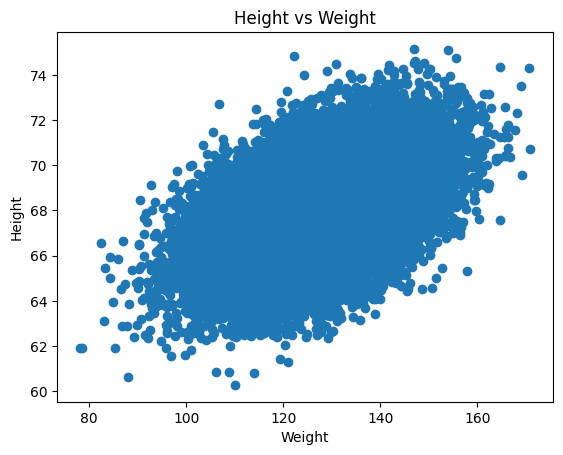

In [38]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')
plt.show()

In [39]:
df.corr()

,Height,Weight
Height,1.000000,0.502859
Weight,0.502859,1.000000


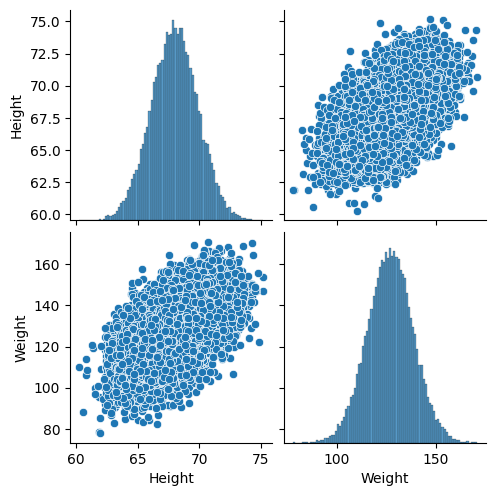

In [40]:
import seaborn as sns
sns.pairplot(df)

In [41]:
#Independent and Dependent Variables
#Independent Variable = Weight, It has to be the dataframe or 2D array.
#Dependent Variable = Height

X = df[['Weight']]
Y = df['Height']

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.90, random_state=42)

In [44]:
X_train.shape

(2500, 1)

Standardization

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

Apply Linear Regression

In [46]:
from sklearn.linear_model import LinearRegression
regression= LinearRegression(n_jobs=-1)
regression.fit(X_train,Y_train)

LinearRegression(n_jobs=-1)

In [47]:
regression.coef_ ## slope (y = mx + c)
regression.intercept_ ## y intercept (y = mx + c)
print("Coefficient or Slope: ",regression.coef_)
print("Intercept or Y intercept: ",regression.intercept_)


Coefficient or Slope:  [0.91728778]
Intercept or Y intercept:  67.99022832


Text(0.5, 1.0, 'Height vs Weight (Training Set)')

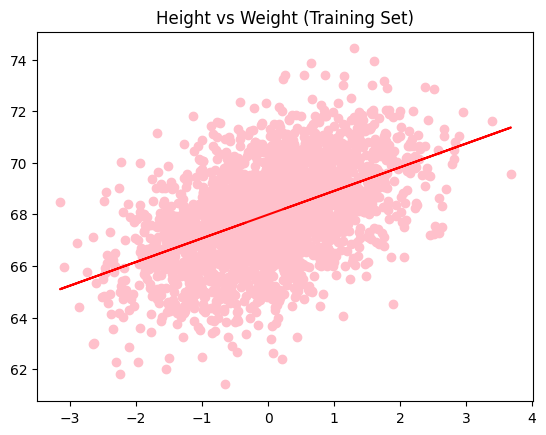

In [48]:
plt.scatter(X_train, Y_train, color='pink')
plt.plot(X_train, regression.predict(X_train), color='red')
plt.title('Height vs Weight (Training Set)')

Prediction of test Data

1. Predicted height output = intercept + coef * Weight
2. y_pred_test = 68.01 + 0.96 * (X_test) -- Test data me weight bhej re hh ji.

In [49]:

y_pred =regression.predict(X_test)

Check the Performance of the Model

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error as rmse

In [51]:
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = rmse(Y_test, y_pred)
print("Mean Squared Error: ", mse)  
print("Mean Absolute Error: ", mae)
print("Root Mean Squared Error: ", rmse)

Mean Squared Error:  2.7060802344133235
Mean Absolute Error:  1.3125015848341315
Root Mean Squared Error:  1.6450167884898086


In [52]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test, y_pred)
print("R2 Score: ", r2)

R2 Score:  0.254008087299335


In [ ]:

ModuleNotFoundError: No module named 'statsmodels'

In [54]:
!pip install statsmodels
import statsmodels.api as sm

model = sm.OLS(Y_train, X_train).fit()
predictions = model.predict(X_test)



[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: C:\Users\mayan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB 682.7 kB/s eta 0:00:15
   ---------------------------------------- 0.1/9.9 MB 919.0 kB/s eta 0:00:11
    --------------------------------------- 0.2/9.9 MB 1.1 MB/s eta 0:00:09
   - -------------------------------------- 0.3/9.9 MB 1.7 MB/s eta 0:00:06
   - -------------------------------------- 0.4/9.9 MB 1.9 MB/s eta 0:00:05
   -- ------------------------------------- 0.6/9.9 MB 2.1 MB/s eta 0:00:05
   -- ------------------------------------- 0.7/9.9 MB 2.2 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.9 MB 2.3 MB/s eta 0:00:04
   --- ------------------------------------ 0.9/9.9 MB 2.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.1/9.9 MB 2.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.2/9.9 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.4/9.9 MB 2.5 MB/s eta 0:00:04
   ------ -----

In [55]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.000
Method:                 Least Squares   F-statistic:                             0.4546
Date:                Wed, 30 Apr 2025   Prob (F-statistic):                       0.500
Time:                        15:50:53   Log-Likelihood:                         -14096.
No. Observations:                2500   AIC:                                  2.819e+04
Df Residuals:                    2499   BIC:                                  2.820e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Prediction of new Data

In [57]:
regression.predict(scaler.transform([[70]]))

C:\Users\mayan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([63.45890138])